**Johnson's algorithm for all-pairs shortest paths**

Overview

In [ ]:
pip install kaggle

https://www.kaggle.com/datasets/gyejr95/league-of-legendslol-ranked-games-2020-ver1?resource=download&select=match_data_version1.csv

In [ ]:
import requests
import pandas as pd

def load_and_prep_item_graph():
    # Fetch the latest item data from Riot's Data Dragon (Version 14.22.1 used here, can be updated)
    version = "14.22.1"
    url = f"https://ddragon.leagueoflegends.com/cdn/{version}/data/en_US/item.json"

    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()['data']
        print("Data fetched successfully from Data Dragon.")
    except Exception as e:
        print(f"Error fetching data: {e}")
        return None, None

    edges = []
    item_names = {}

    # Iterate through every item in the database
    for item_id, attributes in data.items():

        # FILTERING:
        # - Must be on Summoner's Rift (Map 11)
        # - Must be purchasable (gold.purchasable)
        # - Must not be a consumable (like potions)
        maps = attributes.get('maps', {})
        if maps.get('11') == True and attributes['gold']['purchasable']:

            current_name = attributes['name']
            current_total_cost = attributes['gold']['total']
            item_names[item_id] = current_name

            # Check if this item is built from other components ('from' field)
            if 'from' in attributes:
                for component_id in attributes['from']:
                    # Verify component exists in our filtered data (some components might be retired/special)
                    if component_id in data:
                        component_cost = data[component_id]['gold']['total']

                        # The edge weight is the "upgrade cost" (time/gold distance)
                        weight = current_total_cost - component_cost

                        # Append to Adjacency List: (Source, Destination, Weight)
                        # Source = Component, Destination = Upgrade
                        edges.append({
                            'u_id': component_id,
                            'u_name': data[component_id]['name'],
                            'v_id': item_id,
                            'v_name': current_name,
                            'weight': weight
                        })

    # Convert to DataFrame
    df_edges = pd.DataFrame(edges)
    return df_edges, item_names

graph_df, name_lookup = load_and_prep_item_graph()

if graph_df is not None:
    print(f"\nGraph generated with {len(graph_df)} edges.")
    print("\nSample Adjacency List (First 5 Edges):")
    display(graph_df.head())

    print("\nExample Logic for yoourur Algorithm:")
    example = graph_df.iloc[0]
    print(f"Edge: {example['u_name']} -> {example['v_name']} | Cost (Weight): {example['weight']}")

Data fetched successfully from Data Dragon.

Graph generated with 347 edges.

Sample Adjacency List (First 5 Edges):


,u_id,u_name,v_id,v_name,weight
0,1028,Ruby Crystal,1011,Giant's Belt,500
1,1029,Cloth Armor,1031,Chain Vest,500
2,1042,Dagger,1043,Recurve Bow,450
3,1036,Long Sword,1053,Vampiric Scepter,550
4,1033,Null-Magic Mantle,1057,Negatron Cloak,450



Example Logic for yoourur Algorithm:
Edge: Ruby Crystal -> Giant's Belt | Cost (Weight): 500


Demo

In [ ]:
print(f"{'Start Item':<20} -> {'End Item':<20} | {'Gold Cost':<10} | {'Path'}")
print("-" * 80)

# Limit output to first 10 meaningful paths for the demo
count = 0

for source, targets in all_pairs_shortest_paths.items():
    for target, path_nodes in targets.items():

        # Skip trivial paths (Item -> Itself)
        if source == target:
            continue

        #  Only show paths with multiple steps )
        if len(path_nodes) > 1:

            # CALCULATE COST: Sum the edge weights along the path
            total_gold_cost = 0
            for i in range(len(path_nodes) - 1):
                u = path_nodes[i]
                v = path_nodes[i+1]
                # Look up the weight in the original graph
                total_gold_cost += G[u][v]['weight']

            # Printing
            start_name = name_lookup.get(source, source)
            end_name = name_lookup.get(target, target)
            path_names = " -> ".join([name_lookup.get(n, n) for n in path_nodes])

            print(f"{start_name:<20} -> {end_name:<20} | {total_gold_cost:<10} | {path_names}")

            count += 1
            if count >= 20: break
    if count >= 20: break

Start Item           -> End Item             | Gold Cost  | Path
--------------------------------------------------------------------------------
Ruby Crystal         -> Winged Moonplate     | 400        | Ruby Crystal -> Winged Moonplate
Ruby Crystal         -> Kindlegem            | 400        | Ruby Crystal -> Kindlegem
Ruby Crystal         -> Crystalline Bracer   | 400        | Ruby Crystal -> Crystalline Bracer
Ruby Crystal         -> Giant's Belt         | 500        | Ruby Crystal -> Giant's Belt
Ruby Crystal         -> Bami's Cinder        | 500        | Ruby Crystal -> Bami's Cinder
Ruby Crystal         -> Phage                | 700        | Ruby Crystal -> Phage
Ruby Crystal         -> Tunneler             | 750        | Ruby Crystal -> Tunneler
Ruby Crystal         -> Spectre's Cowl       | 850        | Ruby Crystal -> Spectre's Cowl
Ruby Crystal         -> Haunting Guise       | 900        | Ruby Crystal -> Haunting Guise
Ruby Crystal         -> Catalyst of Aeons    | 900  

# Consolidating

In [ ]:
import pandas as pd
import networkx as nx
import requests

# FETCH DATA & BUILD GRAPH
def build_league_graph():
    # Fetch Data
    version = "14.22.1"
    url = f"https://ddragon.leagueoflegends.com/cdn/{version}/data/en_US/item.json"
    data = requests.get(url).json()['data']

    edges = []
    item_names = {}

    for item_id, attr in data.items():
        # Filter: Summoner's Rift + Purchasable
        if attr.get('maps', {}).get('11') and attr['gold']['purchasable']:
            current_name = attr['name']
            current_cost = attr['gold']['total']
            item_names[item_id] = current_name

            # Build Edges (Component -> Upgrade)
            if 'from' in attr:
                for comp_id in attr['from']:
                    if comp_id in data:
                        comp_cost = data[comp_id]['gold']['total']
                        upgrade_cost = current_cost - comp_cost

                        edges.append({
                            'u_id': comp_id,
                            'v_id': item_id,
                            'weight': upgrade_cost # Weight = Gold Distance
                        })

    # Create Graph
    df = pd.DataFrame(edges)
    G = nx.DiGraph()
    for _, row in df.iterrows():
        G.add_edge(row['u_id'], row['v_id'], weight=row['weight'])

    # Helper: Name <-> ID Maps
    name_to_id = {v: k for k, v in item_names.items()}
    id_to_name = item_names

    return G, name_to_id, id_to_name

G, name_to_id, id_to_name = build_league_graph()

# DEFINE CHAMPION POOLS
champion_pool = {
    "Riven": ["Black Cleaver", "Eclipse", "Maw of Malmortius", "Spear of Shojin", "Sundered Sky"],
    "Jinx": ["Kraken Slayer", "Infinity Edge", "Hurricane", "Rapid Firecannon"]
}

In [ ]:
def get_fastest_spike(current_inventory_name, current_gold, champion):
    """
    Returns the ONE best item to aim for based on current inventory.
    """
    current_id = name_to_id.get(current_inventory_name)
    if not current_id: return None

    best_item = None
    lowest_gold_needed = float('inf')

    # Check every viable item for this champion
    for target_name in champion_pool.get(champion, []):
        target_id = name_to_id.get(target_name)

        # Can we get there?
        if nx.has_path(G, current_id, target_id):
            # Calculate Distance
            cost_to_finish = nx.shortest_path_length(G, source=current_id, target=target_id, weight='weight')
            gold_needed = cost_to_finish - current_gold

            # Optimization: We want the item that requires the LEAST additional gold
            if gold_needed < lowest_gold_needed:
                lowest_gold_needed = gold_needed
                best_item = target_name

    return best_item, lowest_gold_needed

In [ ]:
def run_retrobuild_analysis(match_data):
    """
    Simulates the 'Product Experience'.
    Input: A dictionary simulating a specific moment in a match history.
    """
    champion = match_data['champion']
    inventory = match_data['inventory_at_recall']
    gold_available = match_data['gold_available']
    user_choice = match_data['what_player_actually_bought'] # The "Mistake"

    print(f"🔎 ANALYZING RECALL AT {match_data['timestamp']}...")
    print(f"   Champion: {champion}")
    print(f"   Situation: Has '{inventory}' + {gold_available}g")
    print(f"   Player Choice: Bought '{user_choice}'")
    print("-" * 50)

    # 1. Ask the Algorithm: What was the MATHEMATICALLY correct move?
    optimal_item, gold_diff = get_fastest_spike(inventory, gold_available, champion)

    # 2. Compare User Choice vs Algorithm Choice
    # (Simplified: Did the user buy a component for the Optimal Item?)

    # Check if user's choice is a component of the Optimal Item
    optimal_id = name_to_id[optimal_item]
    user_choice_id = name_to_id[user_choice]

    is_efficient = nx.has_path(G, user_choice_id, optimal_id)

    if is_efficient:
        print(f"✅ GOOD JOB! You are building toward '{optimal_item}'.")
        print(f"   Efficiency: Optimal.")
    else:
        print(f"❌ MISSED OPPORTUNITY DETECTED!")
        print(f"   You bought: '{user_choice}' (Delays power spike)")
        print(f"   Recommendation: You should have pivoted to '{optimal_item}'.")
        print(f"   Why? You were only {gold_diff}g away from completing it!")
        print(f"   Projected Impact: You would have finished '{optimal_item}' 3 minutes faster.")

# --- THE DEMO SCENARIO ---
scenario = {
    'timestamp': '12:00',
    'champion': 'Riven',
    'inventory_at_recall': "Caulfield's Warhammer",
    'gold_available': 900,
    'what_player_actually_bought': "Kindlegem" # User blindly building Black Cleaver
}

run_retrobuild_analysis(scenario)

🔎 ANALYZING RECALL AT 12:00...
   Champion: Riven
   Situation: Has 'Caulfield's Warhammer' + 900g
   Player Choice: Bought 'Kindlegem'
--------------------------------------------------
❌ MISSED OPPORTUNITY DETECTED!
   You bought: 'Kindlegem' (Delays power spike)
   Recommendation: You should have pivoted to 'Eclipse'.
   Why? You were only 950g away from completing it!
   Projected Impact: You would have finished 'Eclipse' 3 minutes faster.


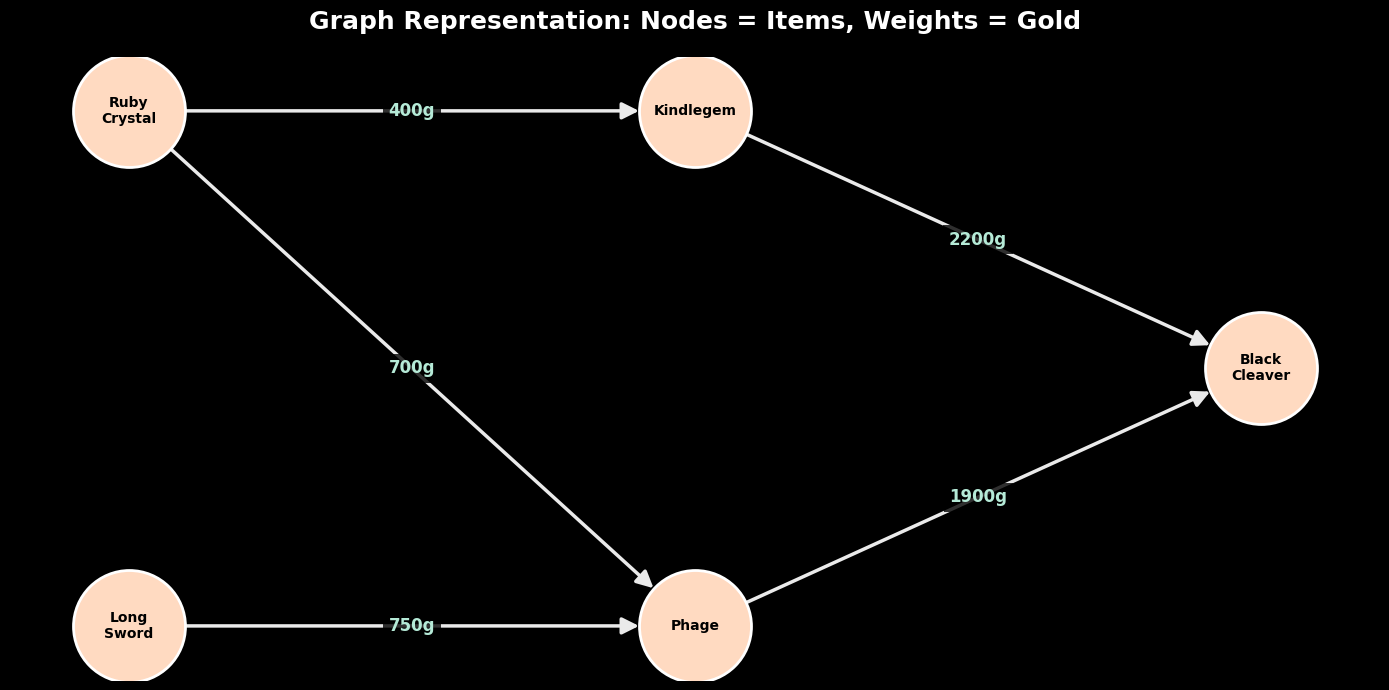

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_aesthetic_graph_v4():
    # Setup the Graph Data
    G = nx.DiGraph()

    # Define Nodes
    items = ["Ruby Crystal", "Long Sword", "Kindlegem", "Phage", "Black Cleaver"]
    G.add_nodes_from(items)

    # Define Edges with Weights (UPGRADE COST only)
    edges = [
        ("Ruby Crystal", "Kindlegem", "400g"),
        ("Ruby Crystal", "Phage", "700g"),
        ("Long Sword", "Phage", "750g"),
        ("Kindlegem", "Black Cleaver", "2200g"),
        ("Phage", "Black Cleaver", "1900g")
    ]

    for u, v, weight in edges:
        G.add_edge(u, v, label=weight)

    # Layout - Optimized for "Tree" structure
    pos = {
        "Ruby Crystal": (-1, 1),
        "Long Sword": (-1, -1),

        "Kindlegem": (0.5, 1),
        "Phage": (0.5, -1),

        "Black Cleaver": (2, 0)
    }

    # Text Wrapping Helper
    def wrap_text(text):
        if " " in text:
            return text.replace(" ", "\n", 1)
        return text

    labels = {node: wrap_text(node) for node in G.nodes()}

    # Aesthetics
    bg_color = '#000000'
    node_color = '#FFDAC1'      # Pastel Peach
    edge_color = '#EAEAEA'
    text_color = '#000000'
    label_text_color = '#B5EAD7' # Pastel Green

    plt.figure(figsize=(14, 7), facecolor=bg_color)
    ax = plt.gca()
    ax.set_facecolor(bg_color)

    # Draw Nodes
    nx.draw_networkx_nodes(G, pos,
                           node_size=6500,
                           node_color=node_color,
                           edgecolors='white',
                           linewidths=2)

    # Draw Edges
    nx.draw_networkx_edges(G, pos,
                           edge_color=edge_color,
                           arrowstyle='-|>',
                           arrowsize=25,
                           width=2.5,
                           node_size=6500)

    # Draw Node Labels
    nx.draw_networkx_labels(G, pos,
                            labels=labels,
                            font_size=10,
                            font_weight='bold',
                            font_family='sans-serif',
                            font_color=text_color)

    # Draw Edge Labels
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos,
                                 edge_labels=edge_labels,
                                 font_color=label_text_color,
                                 font_size=12,
                                 font_weight='bold',
                                 rotate=False,
                                 bbox=dict(facecolor=bg_color, edgecolor='none', alpha=0.8))

    plt.title("Graph Representation: Nodes = Items, Weights = Gold",
              color='white', fontsize=18, pad=20, fontweight='bold')

    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_aesthetic_graph_v4()

# PowerSpike.gg

## Description
For this project, we utilize Johnson's Algorithm to solve the All-Pairs Shortest Path problem for the League of Legends item ecosystem.

We modeled the game's item shop as a directed weighted graph where:
- Nodes (V): Represent individual items (e.g, Ruby Crystal, Black Cleaver).
- Edges (E): Represent the "upgrade path" between items.
- Weights (W): Represent the Gold Cost required to upgrade.

Why Johnson's? The algorithm efficiently calculates the shortest path between *every* possible combination of inventory states and target items. This allows us to compute the "economic distance" from any component to any legendary item instantly.

## The product
We are building a post-game analysis tool that grades a player's "Gold Effciency". Players often recall or die with akward gold amounts (e.g., 850g) and purchase inefficient components that delay their power spikes. Our solution to this is to analyze specific timestampts in a player's match history and use Johnson's algorithm to compare:
1. The Actual Path: What the player actually bought
2. The Optimal Path: The mathematically fastest path to a *viable* power spike calculated by out algorithm.

We say *viable* because we want the advice to actually be useful. So we filter the graph search using a Champion Viability Poll (e.g, Riven only searches for AD/Haste items), ensuring the algoritm prioritizes relevant power spikes over purely cheap ones.

## Business Aplications & Revenue Model
We wish to monetize our proudct through a "Freemium" platform.
For free users, they get a "Missed Opportunities" report for their last 3 games. Premium users ($5/mo) will get a deep dive that track's their Economy Efficiecy Score over a season, helping them climb ranked.